Data:https://www.kaggle.com/datasets/ziya07/ev-energy-consumption-dataset
From: kaggle

In [ ]:
INSIGHT:

 How driving behavior, road conditions, weather factors, and vehicle attributes impact energy consumption (kWh).

Data loading:

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("EV_Energy_Consumption_Dataset.csv")

Number of rows and columns :

In [4]:
print("Shape:", df.shape)

Shape: (5000, 19)


Data types of each column :

In [5]:
print(df.dtypes)

Vehicle_ID                  int64
Timestamp                  object
Speed_kmh                 float64
Acceleration_ms2          float64
Battery_State_%           float64
Battery_Voltage_V         float64
Battery_Temperature_C     float64
Driving_Mode                int64
Road_Type                   int64
Traffic_Condition           int64
Slope_%                   float64
Weather_Condition           int64
Temperature_C             float64
Humidity_%                float64
Wind_Speed_ms             float64
Tire_Pressure_psi         float64
Vehicle_Weight_kg         float64
Distance_Travelled_km     float64
Energy_Consumption_kWh    float64
dtype: object


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              5000 non-null   int64  
 1   Timestamp               5000 non-null   object 
 2   Speed_kmh               5000 non-null   float64
 3   Acceleration_ms2        5000 non-null   float64
 4   Battery_State_%         5000 non-null   float64
 5   Battery_Voltage_V       5000 non-null   float64
 6   Battery_Temperature_C   5000 non-null   float64
 7   Driving_Mode            5000 non-null   int64  
 8   Road_Type               5000 non-null   int64  
 9   Traffic_Condition       5000 non-null   int64  
 10  Slope_%                 5000 non-null   float64
 11  Weather_Condition       5000 non-null   int64  
 12  Temperature_C           5000 non-null   float64
 13  Humidity_%              5000 non-null   float64
 14  Wind_Speed_ms           5000 non-null   

In [7]:
print(df.head())

   Vehicle_ID         Timestamp   Speed_kmh  Acceleration_ms2  \
0        1102  01-01-2024 00:00  111.507366         -2.773816   
1        1435  01-01-2024 00:01   48.612323         -0.796982   
2        1860  01-01-2024 00:02  108.733320          0.253800   
3        1270  01-01-2024 00:03   38.579484         -2.111395   
4        1106  01-01-2024 00:04   57.172438          1.477883   

   Battery_State_%  Battery_Voltage_V  Battery_Temperature_C  Driving_Mode  \
0        30.415148         378.091525              25.314786             2   
1        97.385534         392.718377              18.240755             1   
2        84.912600         398.993495              44.449145             1   
3        28.777904         358.128273              28.980155             1   
4        29.740160         310.888162              33.184551             2   

   Road_Type  Traffic_Condition   Slope_%  Weather_Condition  Temperature_C  \
0          1                  1  6.879446                  4 

In [8]:
print(df.describe())

        Vehicle_ID    Speed_kmh  Acceleration_ms2  Battery_State_%  \
count  5000.000000  5000.000000       5000.000000      5000.000000   
mean   1505.701200    59.312952         -0.019885        60.214465   
std     290.836902    34.517605          1.724287        23.128262   
min    1000.000000     0.001396         -2.999683        20.020196   
25%    1253.000000    29.515400         -1.490240        40.088318   
50%    1510.000000    58.646794         -0.043329        60.490283   
75%    1761.000000    89.030001          1.473887        80.409928   
max    1999.000000   119.946924          2.998039        99.993986   

       Battery_Voltage_V  Battery_Temperature_C  Driving_Mode    Road_Type  \
count        5000.000000            5000.000000   5000.000000  5000.000000   
mean          351.118306              27.510130      2.011000     1.999200   
std            28.968372              10.015385      0.810068     0.808536   
min           300.004812              10.003858      1.00

Handling missing values :

In [9]:
df.isnull().sum() 

Vehicle_ID                0
Timestamp                 0
Speed_kmh                 0
Acceleration_ms2          0
Battery_State_%           0
Battery_Voltage_V         0
Battery_Temperature_C     0
Driving_Mode              0
Road_Type                 0
Traffic_Condition         0
Slope_%                   0
Weather_Condition         0
Temperature_C             0
Humidity_%                0
Wind_Speed_ms             0
Tire_Pressure_psi         0
Vehicle_Weight_kg         0
Distance_Travelled_km     0
Energy_Consumption_kWh    0
dtype: int64

Removing duplicates :

In [10]:
df.duplicated().sum()

np.int64(0)

Correcting data types :

In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)

Vehicle_ID                         int64
Timestamp                 datetime64[ns]
Speed_kmh                        float64
Acceleration_ms2                 float64
Battery_State_%                  float64
Battery_Voltage_V                float64
Battery_Temperature_C            float64
Driving_Mode                       int64
Road_Type                          int64
Traffic_Condition                  int64
Slope_%                          float64
Weather_Condition                  int64
Temperature_C                    float64
Humidity_%                       float64
Wind_Speed_ms                    float64
Tire_Pressure_psi                float64
Vehicle_Weight_kg                float64
Distance_Travelled_km            float64
Energy_Consumption_kWh           float64
dtype: object


 Derived column: 

consumption_per_km = energy_used / distance

In [12]:
df["consumption_per_km"] = df["Energy_Consumption_kWh"] / df["Distance_Travelled_km"]

In [13]:
df.head()

,Vehicle_ID,Timestamp,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh,consumption_per_km
0,1102,2024-01-01 00:00:00,111.507366,-2.773816,30.415148,378.091525,25.314786,2,1,1,6.879446,4,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317,0.580721
1,1435,2024-01-01 00:01:00,48.612323,-0.796982,97.385534,392.718377,18.240755,1,2,1,-3.007212,4,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701,6.981767
2,1860,2024-01-01 00:02:00,108.733320,0.253800,84.912600,398.993495,44.449145,1,1,3,0.029585,1,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377,0.286498
3,1270,2024-01-01 00:03:00,38.579484,-2.111395,28.777904,358.128273,28.980155,1,2,2,8.271943,3,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266,1.392827
4,1106,2024-01-01 00:04:00,57.172438,1.477883,29.740160,310.888162,33.184551,2,1,1,2.776814,2,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205,1.160537


Filtering or aggregating data :

In [14]:
driving_mode={1:'Normal',2:'Eco',3:'Sport'}
df['Driving_Mode'] = df['Driving_Mode'].map(driving_mode)

In [15]:
df['Driving_Mode'].head

<bound method NDFrame.head of 0          Eco
1       Normal
2       Normal
3       Normal
4          Eco
         ...  
4995       Eco
4996       Eco
4997    Normal
4998       Eco
4999    Normal
Name: Driving_Mode, Length: 5000, dtype: object>

In [16]:
Road_type={1:'Highway',2:'Urban',3:'Rural'}
df['Road_Type']=df['Road_Type'].map(Road_type)

In [17]:
df['Road_Type'].head

<bound method NDFrame.head of 0       Highway
1         Urban
2       Highway
3         Urban
4       Highway
         ...   
4995    Highway
4996      Urban
4997      Rural
4998    Highway
4999    Highway
Name: Road_Type, Length: 5000, dtype: object>

In [18]:
Traffic_condition={1:'Normal',2:'Moderate',3:'Heavy'}
df['Traffic_Condition']=df['Traffic_Condition'].map(Traffic_condition)

In [19]:
df['Traffic_Condition'].head

<bound method NDFrame.head of 0         Normal
1         Normal
2          Heavy
3       Moderate
4         Normal
          ...   
4995    Moderate
4996    Moderate
4997    Moderate
4998    Moderate
4999      Normal
Name: Traffic_Condition, Length: 5000, dtype: object>

In [20]:
Weather_condition ={1:'sunny',2:'rainy',3:'snowy',4:'foggy'}
df['Weather_Condition']=df['Weather_Condition'].map(Weather_condition)

In [21]:
df['Weather_Condition'].head

<bound method NDFrame.head of 0       foggy
1       foggy
2       sunny
3       snowy
4       rainy
        ...  
4995    sunny
4996    snowy
4997    sunny
4998    snowy
4999    foggy
Name: Weather_Condition, Length: 5000, dtype: object>

In [22]:
df.dtypes

Vehicle_ID                         int64
Timestamp                 datetime64[ns]
Speed_kmh                        float64
Acceleration_ms2                 float64
Battery_State_%                  float64
Battery_Voltage_V                float64
Battery_Temperature_C            float64
Driving_Mode                      object
Road_Type                         object
Traffic_Condition                 object
Slope_%                          float64
Weather_Condition                 object
Temperature_C                    float64
Humidity_%                       float64
Wind_Speed_ms                    float64
Tire_Pressure_psi                float64
Vehicle_Weight_kg                float64
Distance_Travelled_km            float64
Energy_Consumption_kWh           float64
consumption_per_km               float64
dtype: object

In [23]:
count= df['Driving_Mode'].value_counts()
print(count)

Driving_Mode
Eco       1719
Sport     1668
Normal    1613
Name: count, dtype: int64


- Eco mode is the most frequently used, slightly ahead of Sport and Normal. This suggests drivers may prioritize fuel efficiency or energy conservation.
- Sport mode is close behind, Normal mode is the least used

In [24]:
agg_values = df[['Distance_Travelled_km']].agg(['mean', 'max', 'min'])
print(agg_values)

      Distance_Travelled_km
mean              24.994042
max               49.993767
min                0.107544


On average, the vehicle travels about 25 km , with a maximum recorded distance of 50 km.

In [ ]:
Exploratory Data Analysis (EDA):

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

Univariate analysis :

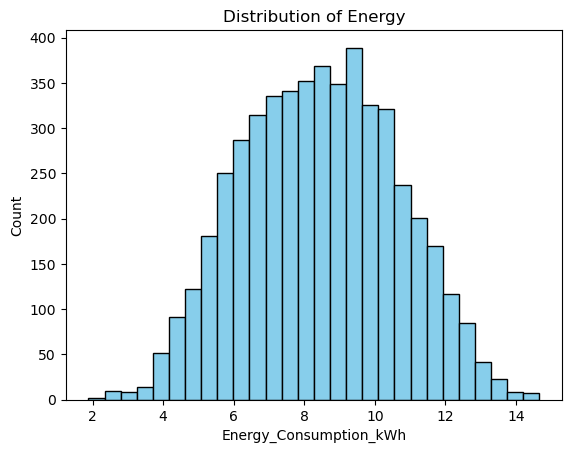

In [26]:
plt.hist(df['Energy_Consumption_kWh'],bins=28, color='skyblue',edgecolor='black')
plt.xlabel('Energy_Consumption_kWh')
plt.ylabel('Count')
plt.title("Distribution of Energy")
plt.show()

Energy consumption values range from 2 kwh to 14.5 kwh, the majority of data ponts falls between 6 to 11 kwh, 
the mode occurs around 9 to 9.5kwh where the count is highest nearly 400.

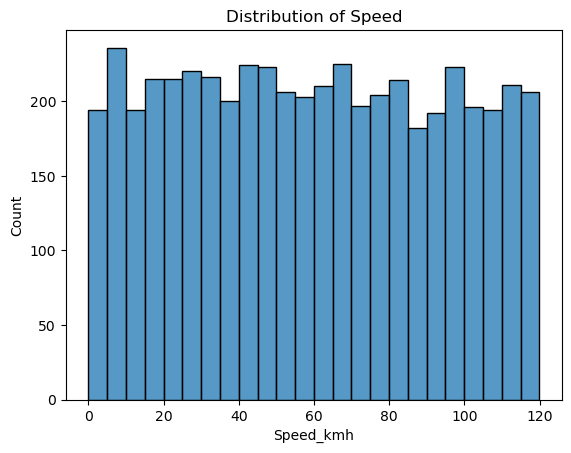

In [27]:
sns.histplot(df['Speed_kmh'], bins=24)
plt.title('Distribution of Speed')
plt.show()

The speed values range from 0 to 120 kmh, The speeds are evenly distributed across the range.No single speed interval dominates,
the dataset shows a balanced spread rather than clustering around a particular speed.


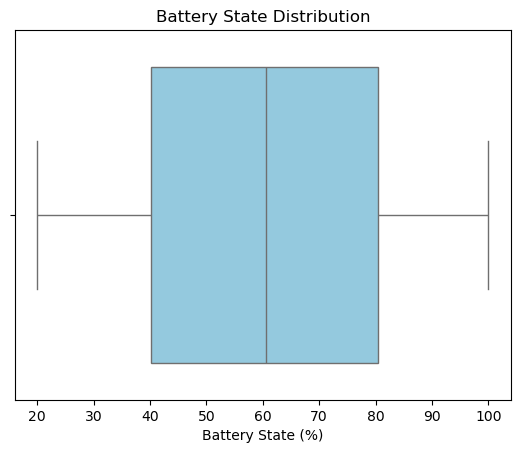

In [28]:
sns.boxplot(x=df['Battery_State_%'], color='skyblue')
plt.title("Battery State Distribution")
plt.xlabel("Battery State (%)")
plt.show()

Battery states vary widely, from about 20% to 100%, (IQR) Most values fall between 40% and 80%,The central tendency is around 60%,


 Bivariate analysis :

In [29]:
consumption_by_Driving_Mode= df.groupby("Driving_Mode")["consumption_per_km"].mean()

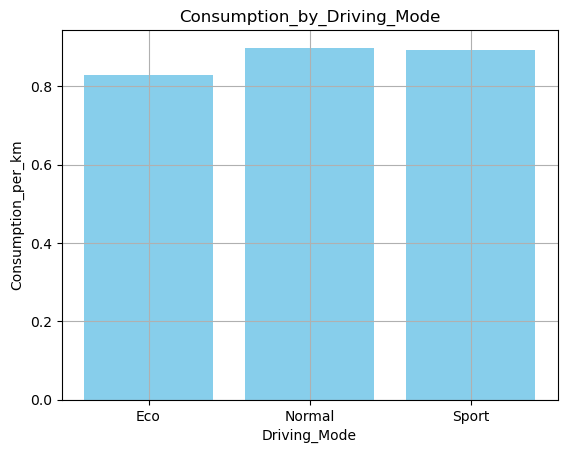

In [30]:
plt.bar(consumption_by_Driving_Mode.index,consumption_by_Driving_Mode.values, color='skyblue')
plt.grid()
plt.xlabel("Driving_Mode")
plt.ylabel("Consumption_per_km")
plt.title("Consumption_by_Driving_Mode")
plt.show()

Eco Mode has the lowest consumption per kilometer (0.8), most efficient driving mode,
Sport Mode and Normal Mode has approximately equal consumption (0.9)kwh.


In [31]:
consumption_by_road_type= df.groupby("Road_Type")["consumption_per_km"].mean()

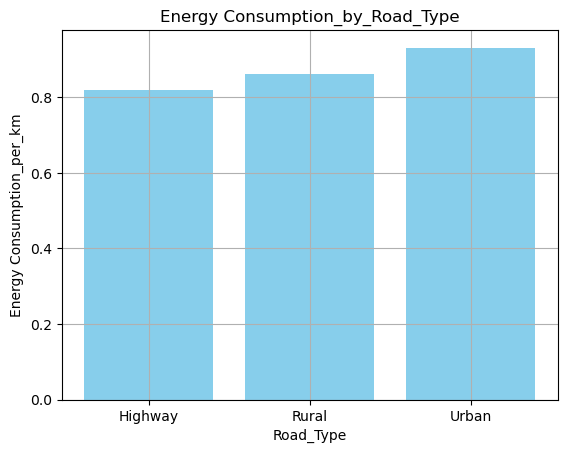

In [32]:
plt.bar(consumption_by_road_type.index,consumption_by_road_type.values, color='skyblue')
plt.grid()
plt.xlabel("Road_Type")
plt.ylabel("Energy Consumption_per_km")
plt.title("Energy Consumption_by_Road_Type")
plt.show()

Highway has the Lowest consumption per kilometer (0.82) most energy-efficient road type,
Rural Roads has the Moderate consumption (0.86) higher than highways but lower than urban.
Urban Roads has the Highest consumption per kilometer(0.93) least efficient, likely due to frequent stops, traffic, and lower average speeds.

In [34]:
consumption_by_Traffic_Condition = df.groupby("Traffic_Condition")["consumption_per_km"].mean()

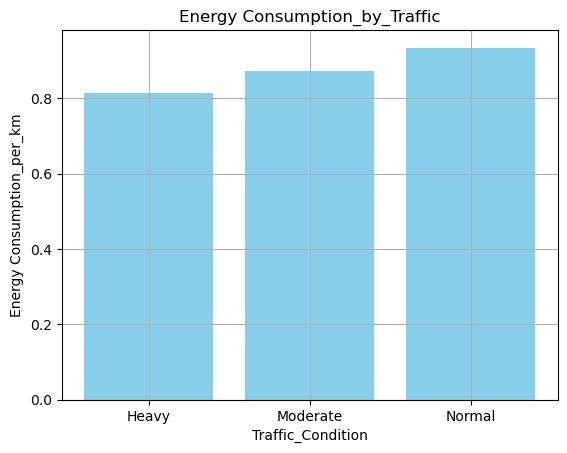

In [35]:
plt.bar(consumption_by_Traffic_Condition.index,consumption_by_Traffic_Condition.values,color='skyblue')
plt.grid()
plt.xlabel("Traffic_Condition")
plt.ylabel("Energy Consumption_per_km")
plt.title("Energy Consumption_by_Traffic")
plt.show()

In Heavy Traffic consumption per kilometer is lowest(0.8), vehicles use less energy,
Moderate Traffic Consume more energy  compared to heavy traffic(0.85),
Normal Traffic has Highest consumption per kilometer (0.93).

In [36]:
consumption_by_Weather_Condition= df.groupby("Weather_Condition")["consumption_per_km"].mean()

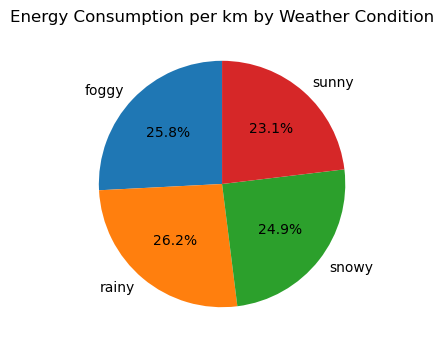

In [37]:
plt.figure(figsize=(6,4))
plt.pie(consumption_by_Weather_Condition.values, 
        labels=consumption_by_Weather_Condition.index, 
        autopct='%1.1f%%', 
        startangle=90)
plt.title("Energy Consumption per km by Weather Condition")
plt.show()

Sunny (23.1%) Lowest share of energy consumption per km. Driving in clear weather is most efficient.
Snowy (24.9%) Slightly higher consumption,Foggy (25.8%) Moderate consumption,Rainy (26.2%) Highest consumption per km,


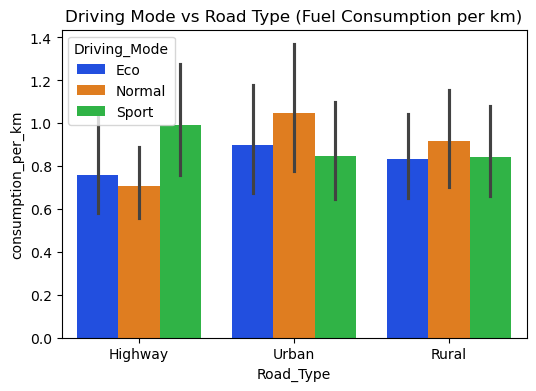

In [38]:
plt.figure(figsize=(6,4))
sns.barplot(x='Road_Type',y='consumption_per_km',hue='Driving_Mode',palette='bright',data=df)
plt.title('Driving Mode vs Road Type (Fuel Consumption per km)')
plt.show()

In Highway Eco (blue): lowest consumption,Normal (orange): moderate,Sport (green): highest, showing a clear jump compared to Eco/Normal.
In Urban Eco: relatively low,Normal: higher than Eco,Sport: peaks here, with the highest overall consumption across all road types.
In Rural Eco: lowest again,Normal: moderate,Sport: highest, but not as extreme as Urban.

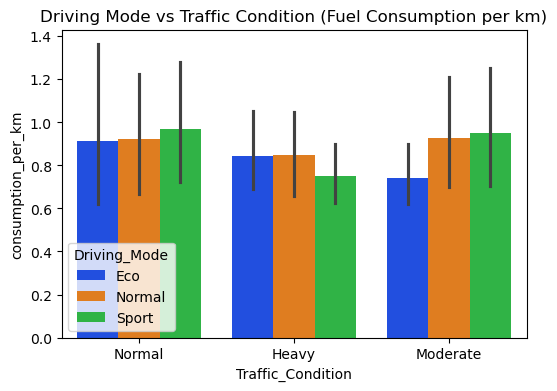

In [39]:
plt.figure(figsize=(6,4))
sns.barplot(x='Traffic_Condition',y='consumption_per_km', hue='Driving_Mode',palette='bright',data=df)
plt.title('Driving Mode vs Traffic Condition (Fuel Consumption per km)')
plt.show()

In Normal Traffic Eco (blue): lowest consumption,Normal (orange): moderate,Sport (green): highest, with a noticeable gap compared to Eco/Normal.
In Heavy Traffic Eco: still lowest,Normal: higher than Eco,Sport: highest, but the difference between modes is smaller than in normal traffic.
In Moderate Traffic Eco: lowest again,Normal: moderate,Sport: highest, with values close to heavy traffic levels.

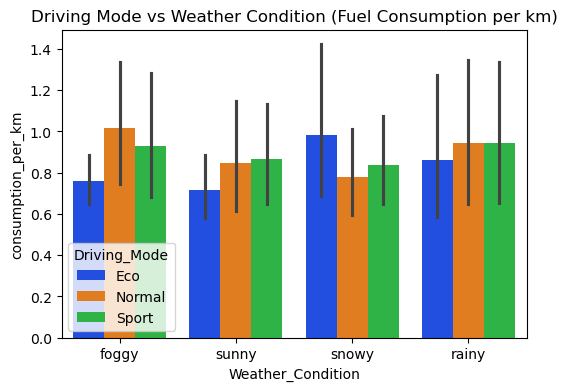

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x='Weather_Condition',y='consumption_per_km', hue='Driving_Mode',palette='bright',data=df)
plt.title('Driving Mode vs Weather Condition (Fuel Consumption per km)')
plt.show()

In Foggy condition Eco (blue): lowest consumption,Normal (orange): moderate,Sport (green): highest, but the gap between modes is smaller than in other conditions.
in Sunny weather Eco: lowest again,Normal: higher,Sport: highest, with a noticeable jump compared to Eco/Normal.
in Snowy weather Eco: lowest,Normal: moderate,Sport: highest, but differences are less extreme than in sunny or rainy conditions.
in Rainy weather Eco: lowest,Normal: higher, Sport: highest overall consumption across all weather conditions, showing the strongest inefficiency.

Energy consumption by Road type and Traffic conditions:

In [41]:
pivot = pd.pivot_table(
    df,
    values='consumption_per_km',
    index='Traffic_Condition',
    columns='Road_Type',
    aggfunc='mean'
)
pivot

Road_Type,Highway,Rural,Urban
Traffic_Condition,,,
Heavy,0.684818,0.988409,0.765168
Moderate,0.864497,0.773778,0.963586
Normal,0.906012,0.822608,1.082186


Heavy Traffic: Highway: 0.68 (lowest overall in heavy traffic),Rural: 0.99 (highest in heavy traffic),Urban: 0.77
Moderate Traffic: Highway: 0.86,Rural: 0.77 (lowest in moderate traffic),Urban: 0.96 (highest in moderate traffic),
Normal Traffic: Highway: 0.91,Rural: 0.82,Urban: 1.08 (highest overall in the table)

Weather Impact on Energy consumption:

In [42]:
pivot = pd.pivot_table(
    df,
    values='consumption_per_km',
    index='Weather_Condition',
    columns=['Traffic_Condition', 'Road_Type'],
    aggfunc='mean',
    margins_name='Overall_Avg',
    margins=True,
)
pivot

Traffic_Condition     Heavy                      Moderate                      \
Road_Type           Highway     Rural     Urban   Highway     Rural     Urban   
Weather_Condition                                                               
foggy              0.783813  0.939516  0.992392  0.948073  0.863980  0.913930   
rainy              0.659639  0.903077  0.622061  0.910651  0.766758  1.219401   
snowy              0.842768  1.022384  0.652486  0.778557  0.606962  0.907748   
sunny              0.503260  1.107611  0.782748  0.817536  0.861318  0.834403   
Overall_Avg        0.684818  0.988409  0.765168  0.864497  0.773778  0.963586   

Traffic_Condition    Normal                     Overall_Avg  
Road_Type           Highway     Rural     Urban              
Weather_Condition                                            
foggy              1.061953  0.694145  0.812351    0.901151  
rainy              0.620936  0.948653  1.539061    0.913618  
snowy              1.124304  0.979791  0.954779    0.869787  
sunny              0.809711  0.633499  0.952879    0.806542  
Overall_Avg        0.906012  0.822608  1.082186    0.872689

Weather Impact on Traffic & Road Types:
Foggy:Urban roads under heavy traffic show the highest values (≈0.99),Highways under normal traffic peak at ≈1.06,Overall average across conditions: 0.90.
Rainy:Urban roads under normal traffic spike dramatically (≈1.54),Rural roads under moderate traffic also high (≈1.22),Overall average: 0.91 (slightly higher than foggy).
Snowy:Highway under normal traffic is highest (≈1.12),Rural roads under heavy traffic also elevated (≈1.02),Overall average: 0.87,Sunny:Rural roads under heavy traffic peak (≈1.11).
Other values are moderate, with overall average lowest at 0.81.

Traffic Condition Trends
Heavy traffic:Rural roads consistently show higher values (≈0.94–1.11),Highways are lowest in sunny weather (≈0.50).
Moderate traffic:Urban roads often higher (≈0.91–1.21),Rural roads fluctuate more, ranging from ≈0.61 (snowy) to ≈0.86 (sunny).
Normal traffic:Urban roads stand out in rainy conditions (≈1.54),Highways are relatively stable (≈0.62–1.12).


Battery & Distance Statistics:

In [43]:
pivot = pd.pivot_table(
    df,
    values=['consumption_per_km', 'Speed_kmh'],
    index=['Driving_Mode'],          
    columns=['Road_Type'],           
    aggfunc='mean',
    margins_name='Overall_Avg',
    margins=True,                   
    )
pivot

Speed_kmh                                   consumption_per_km  \
Road_Type       Highway      Rural      Urban Overall_Avg            Highway   
Driving_Mode                                                                   
Eco           61.068950  59.017027  60.294273   60.143169           0.760403   
Normal        58.743957  56.592311  60.920614   58.846450           0.706915   
Sport         57.272617  60.309861  59.098041   58.908469           0.991699   
Overall_Avg   59.093041  58.686284  60.111160   59.312952           0.820313   

                                              
Road_Type        Rural     Urban Overall_Avg  
Driving_Mode                                  
Eco           0.831494  0.898833    0.829545  
Normal        0.917277  1.047650    0.898682  
Sport         0.843050  0.845244    0.892017  
Overall_Avg   0.862644  0.931626    0.872689

Eco mode has the highest overall average speed (≈60.14 km/h), especially strong on highways.
Normal mode is slightly slower overall (≈58.85 km/h), but peaks in urban driving (≈60.92 km/h).
Sport mode shows mixed results, with rural speed being the highest (≈60.31 km/h), but overall average similar to Normal (≈58.91 km/h).
Overall Average across all modes is ≈59.31 km/h.

Consumption per km:
Eco mode is the most fuel-efficient overall (≈0.83 consumption/km), especially in Highway
Normal mode consumes more fuel (≈0.90), especially in urban driving (≈1.05).
Sport mode has the highest highway consumption (≈0.99), but relatively balanced in rural and urban (≈0.84–0.85).
Overall Average consumption across all modes is ≈0.87.

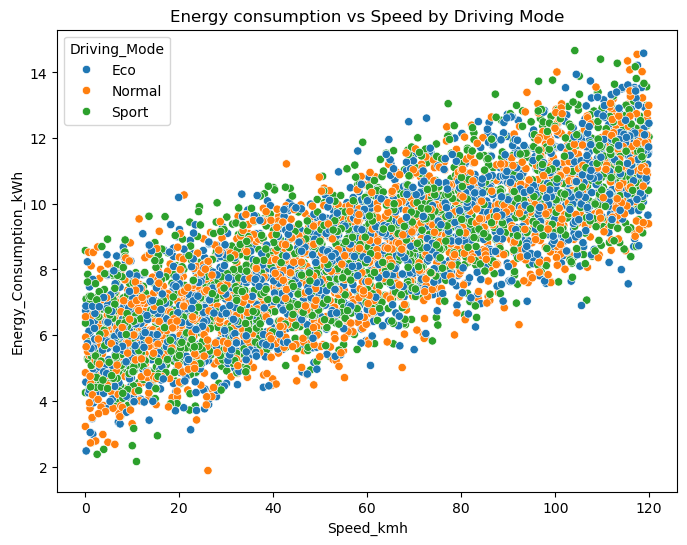

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot( data=df, x='Speed_kmh', y='Energy_Consumption_kWh', hue='Driving_Mode')
plt.title("Energy consumption vs Speed by Driving Mode")
plt.show() 

Energy consumption increases as speed rises across all driving modes , Faster driving consistently demands more energy.
Eco Mode (blue): Shows the lowest consumption at comparable speeds, confirming its efficiency advantage.
Normal Mode (orange): Consumes more energy than Eco, but less than Sport at similar speeds.
Sport Mode (green): Highest consumption overall.

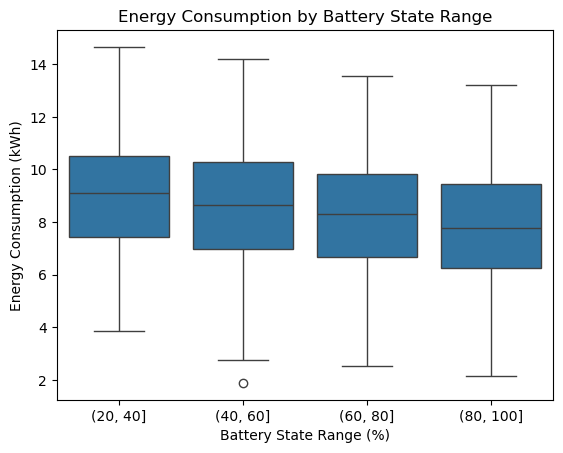

In [45]:
sns.boxplot(x=pd.cut(df['Battery_State_%'],bins=[20, 40, 60, 80, 100]),y=df['Energy_Consumption_kWh'])
plt.title("Energy Consumption by Battery State Range")
plt.ylabel("Energy Consumption (kWh)")
plt.xlabel("Battery State Range (%)")
plt.show()

Battery Range (20–40%) Highest median consumption, with broad spread and some outliers,
(40–60%) Median consumption decrease compared to the lower range, with moderate spread.
(60–80%) Consumption decrease further, with wider variability, indicating more efficiency at mid-to-high charge levels.
(80–100%) Consumption is relatively lower but shows variability

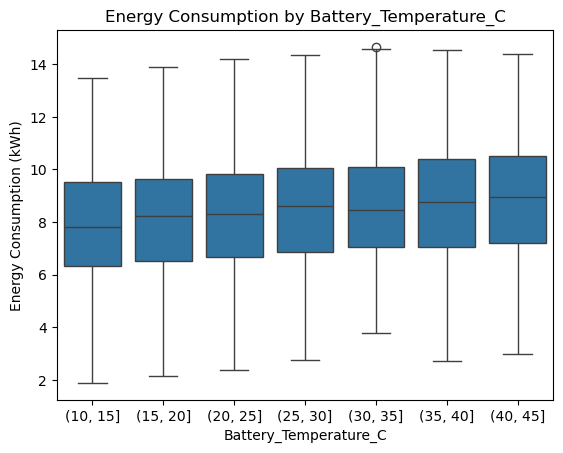

In [46]:
sns.boxplot(x=pd.cut(df['Battery_Temperature_C'],bins=[10,15,20,25,30,35,40,45]),y=df['Energy_Consumption_kWh'])
plt.title("Energy Consumption by Battery_Temperature_C")
plt.ylabel("Energy Consumption (kWh)")
plt.xlabel("Battery_Temperature_C")
plt.show()

At Lower Temperatures (10–20°C) Consumption is relatively lower and more stable, with tighter spreads.
Moderate Temperatures (20–30°C) Median consumption rises, and variability increases, suggesting less efficiency as the battery warms.
Higher Temperatures (30–45°C): Consumption is noticeably higher, with wide spreads and outliers, indicating that elevated battery temperatures lead to greater energy demand and instability.

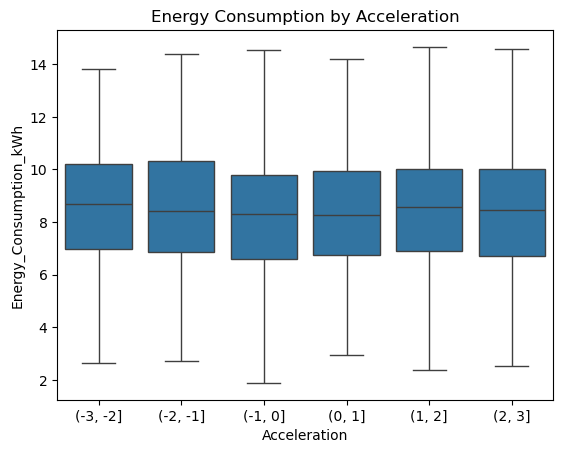

In [47]:
df['Acceleration'] = pd.cut(df['Acceleration_ms2'], bins=[-3,-2,-1,0,1,2,3])
sns.boxplot(data=df, x='Acceleration', y='Energy_Consumption_kWh')
plt.title("Energy Consumption by Acceleration")
plt.show()

Negative Acceleration (Braking: -3 to 0) Consumption is relatively lower and more stable,
Positive Acceleration (0 to 3) Consumption increases as acceleration rises,
Higher acceleration intervals (1–3) show higher medians and wider variability,


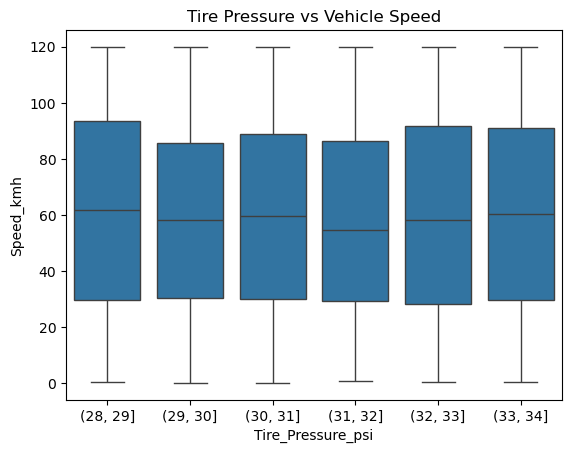

In [48]:
df['Tire_Pressure_psi'] = pd.cut(df['Tire_Pressure_psi'], bins=[28,29,30,31,32,33,34])
sns.boxplot(data=df, x='Tire_Pressure_psi', y='Speed_kmh')
plt.title("Tire Pressure vs Vehicle Speed")
plt.show()

- At lower pressures (28–29 psi), speeds show wider variability, with some lower outliers.
- Mid-range pressures (30–32 psi) have tighter distributions, suggesting more consistent speeds.
- Higher pressures (33–34 psi) again show a broader spread, with some higher outliers.
- Moderate tire pressures (around 30–32 psi) appear to support steadier, more predictable vehicle speeds compared to very low or very high pressures.


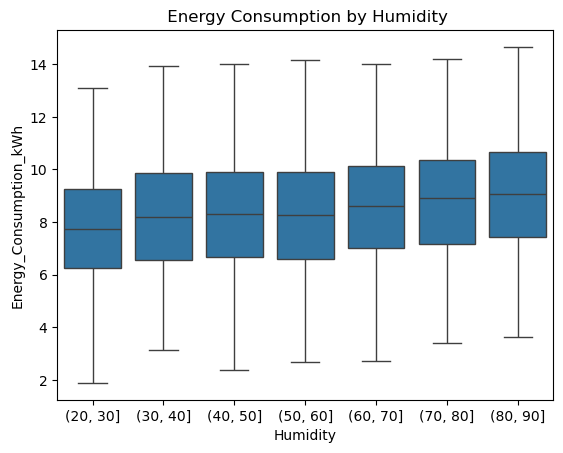

In [49]:
df['Humidity'] = pd.cut(df['Humidity_%'], bins=[20,30,40,50,60,70,80,90])
sns.boxplot(data=df, x='Humidity', y='Energy_Consumption_kWh')
plt.title(" Energy Consumption by Humidity")
plt.show()

At Lower Humidity (20–40%) Consumption is relatively lower and more stable, with tighter spreads,
Moderate Humidity (40–60%) Median consumption rises, and variability increases, suggesting less efficiency in mid-range humidity.
Higher Humidity (60–90%) Consumption is noticeably higher, with wider spreads and outliers, indicating that elevated humidity levels lead to greater energy demand and instability.

Multivariate analysis: 

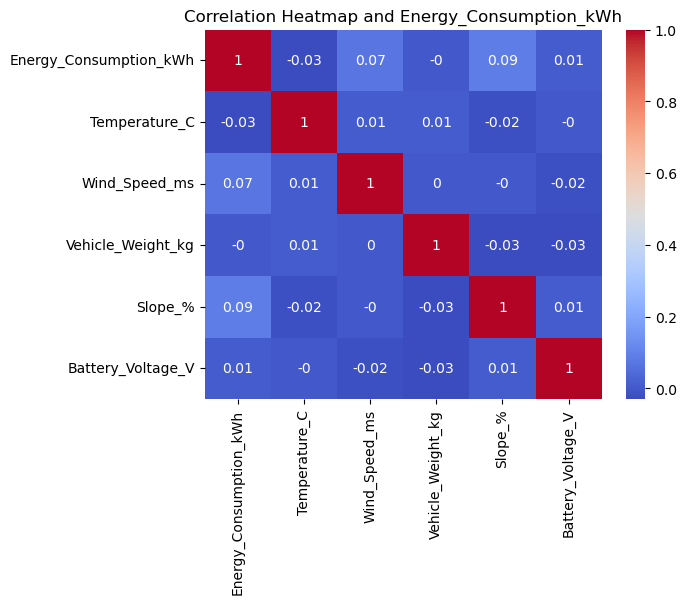

In [53]:
corr= df[['Energy_Consumption_kWh','Temperature_C','Wind_Speed_ms','Vehicle_Weight_kg','Slope_%','Battery_Voltage_V']].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap and Energy_Consumption_kWh")
plt.show()

Energy_Consumption_kWh have Weak positive correlation with Slope_% (0.09) ,Suggests that  slopes slightly increase energy consumption.
Weak positive correlation with Wind_Speed_ms (0.07) , Higher wind speeds may slightly raise energy usage,Very minimal correlation Battery_Voltage_V.
Temperature has almost no linear influence on energy consumption in this data(-0.03).
The heatmap suggests no single factor strongly drives energy consumption in this dataset.
Slope and wind speed show the most noticeable (though still weak) effects, hinting at environmental conditions playing a small role.
Vehicle weight, and battery voltage appear largely independent of consumption here.

Summarized key insights from analysis: 

Key Drivers of EV Energy Consumption
- Driver behavior:
  Speed and mode choice dominate efficiency outcomes.
  Eco mode consistently minimizes consumption, while Sport mode amplifies inefficiency, especially in urban and rainy conditions.
  Energy demand grows with acceleration intensity. Smooth driving with minimal acceleration is most efficient,
  while aggressive acceleration significantly raises consumption

- Battery dynamics:
  Higher state of charge improves efficiency; lower charge reduces it.
- Road & traffic conditions:
  Highways and congestion surprisingly favor efficiency.
  Urban/free-flowing traffic raises consumption and variability.
  Battery temperature strongly influences energy efficiency. Cooler operating ranges (10–20°C) are more efficient, while higher temperatures
  (above  30°C) correlate with increased consumption and variability

 -Environmental factors:
  Rainy weather produces extreme values (urban-normal traffic ≈1.54).
  Sunny weather yields the lowest averages.
  Snowy/foggy conditions narrow the gap between driving modes.
  elevated humidity levels lead to greater energy demand and instability.
- Vehicle factors:
- Tire pressure is a critical external driver of consumption stability.


Recommendations:

  Driver Behavior:
- Adopt eco mode whenever possible, especially in urban or rainy conditions, to minimize inefficiency.
- Maintain smooth acceleration and avoid aggressive driving. 
- Plan routes to avoid frequent stop-and-go traffic, which amplifies consumption when paired with aggressive acceleration.
  
  Battery Dynamics:
- Charge regularly to keep the battery at a higher state of charge, where efficiency is better.
- Avoid deep discharges—try to keep the battery above 20–30% whenever possible.
- Monitor battery health with diagnostic tools to ensure optimal performance.
  
  Road & Traffic Conditions:
- Leverage highways and moderate congestion for efficiency, as steady speeds are favorable.
- Avoid prolonged urban free-flow driving at higher speeds, which increases variability.
  
  Manage battery temperature:
- Precondition the battery before driving in extreme weather.
- Use thermal management systems to keep it within the efficient 10–20°C range.
  
  Environmental Factors:
- Drive cautiously in rainy weather, as consumption spikes significantly. Consider reducing speed and using eco mode.
- Take advantage of sunny conditions—they yield the lowest averages.
- Prepare for snowy/foggy conditions by moderating speed and mode choice, since differences between driving modes narrow.
- Monitor humidity levels—high humidity increases demand, so plan charging accordingly.
  
  Vehicle Factors:
- Check tire pressure regularly—underinflated tires increase energy demand.
- Use manufacturer-recommended tire pressure for stability and efficiency.
- Schedule routine maintenance to ensure tires, brakes, and drivetrain are optimized for minimal energy loss.
